PHASE 1: LOADING DATA
Application Train Shape: (307511, 122)
Bureau Shape: (1716428, 17)
Bureau Balance Shape: (27299925, 3)
Previous Application Shape: (1670214, 37)
POS Cash Shape: (10001358, 8)
Installments Shape: (13605401, 8)
Credit Card Shape: (3840312, 23)

PHASE 2: EXPLORATORY DATA ANALYSIS

Target Variable Distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target Imbalance Ratio:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

PHASE 3: DATA PREPROCESSING - FEATURE CONCATENATION
Shape after feature concatenation: (307511, 317)

PHASE 4: HANDLING MISSING VALUES
Shape after cleaning: (307511, 207)

PHASE 5: FEATURE ENCODING & NORMALIZATION
Data normalized. Shape: (307511, 205)

PHASE 6: HANDLING CLASS IMBALANCE - DOWN-SAMPLING
Train set size: (39720, 205)
Test set size: (9930, 205)

PHASE 7: MODEL TRAINING & EVALUATION

[1/6] Training Logistic Regression...
✓ Accuracy: 0.6997, F1: 0.7004
[2/6] Training Decision Tree...
✓ Accuracy: 0.5910,

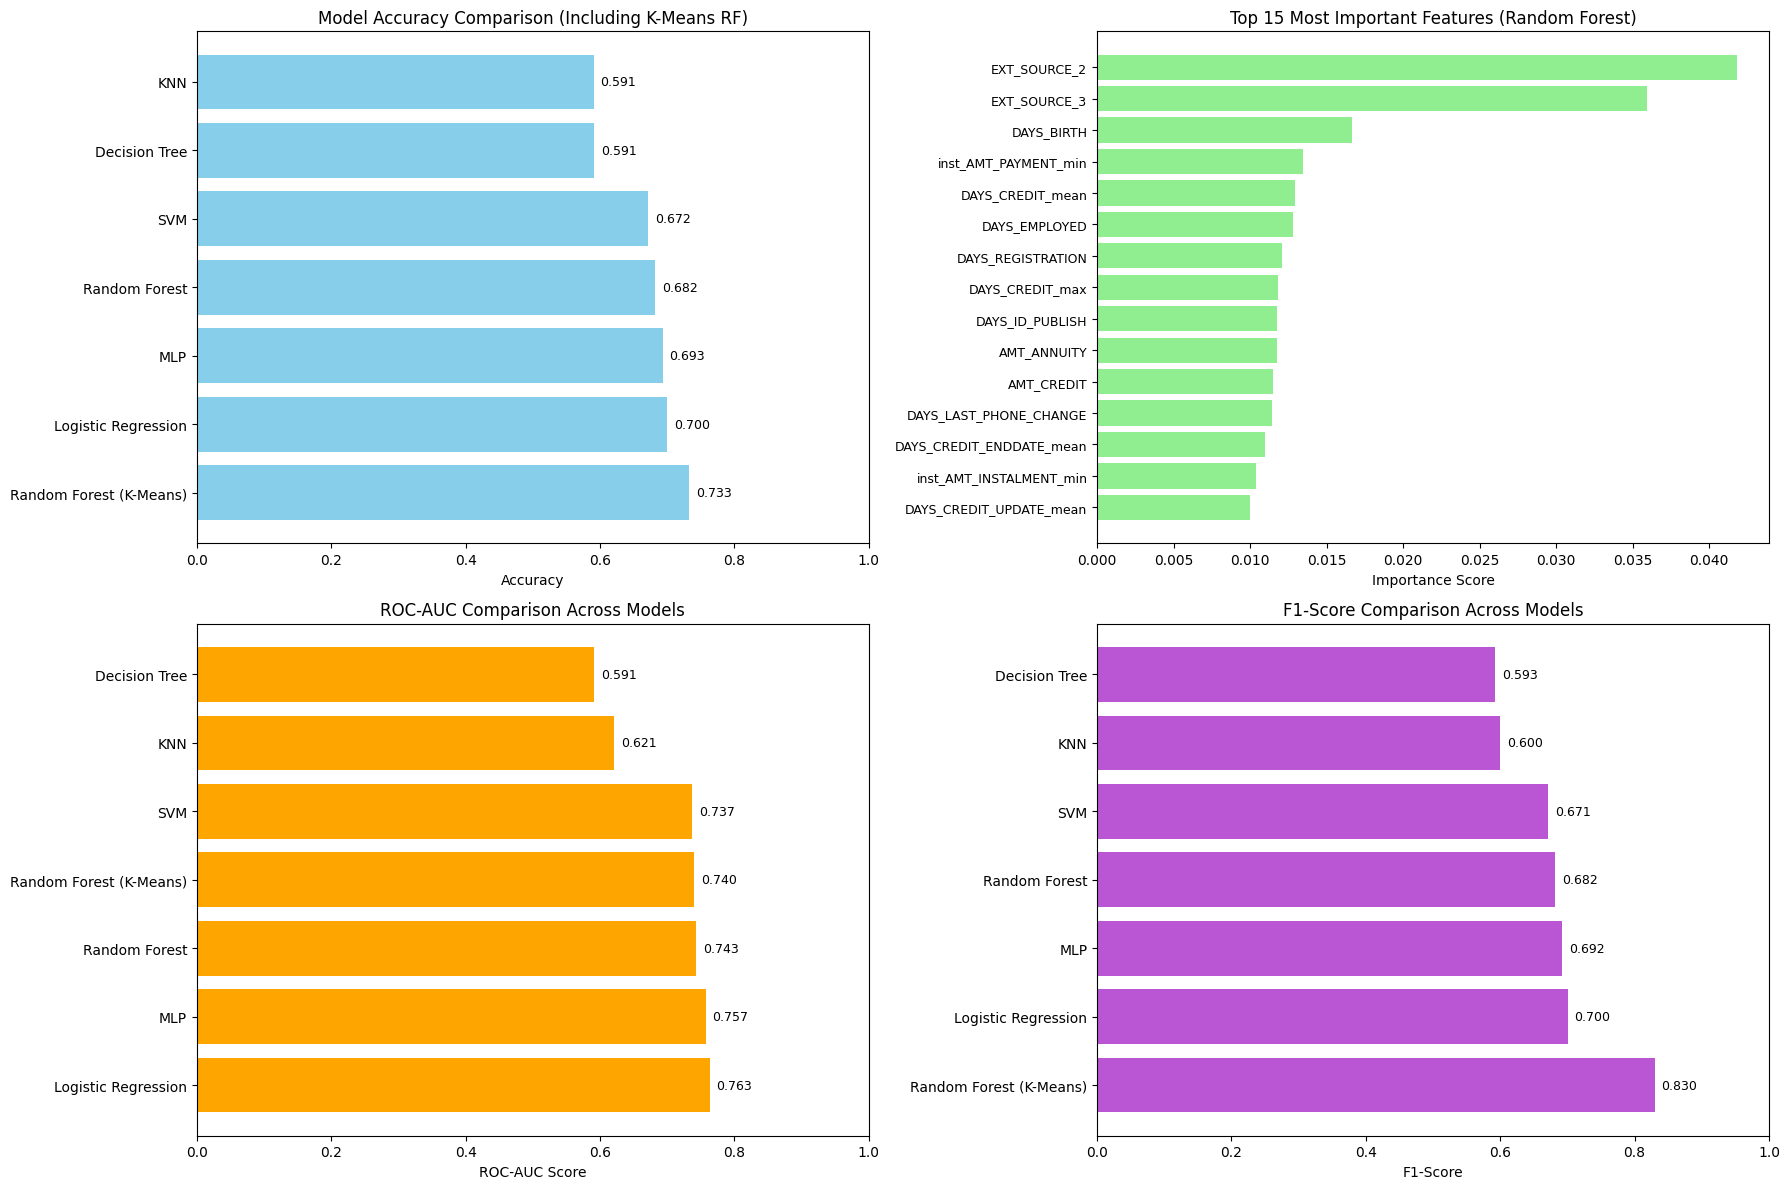


FINAL SUMMARY

✓ Best Model (Accuracy): Logistic Regression (0.6997)
✓ Best Model (F1-Score): Logistic Regression (0.7004)
✓ Best Model (ROC-AUC): Logistic Regression (0.7629)

✓ Most Important Feature: EXT_SOURCE_2 (Importance: 0.0418)
✓ Second Important Feature: EXT_SOURCE_3 (Importance: 0.0359)



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# ===================== SET OUTPUT PATH =====================
OUTPUT_PATH = r"C:\Users\shrey\Desktop\ML"
os.makedirs(OUTPUT_PATH, exist_ok=True)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier
import time

# ===================== 1. LOAD DATA =====================
print("=" * 80)
print("PHASE 1: LOADING DATA")
print("=" * 80)

base_path = r"C:\Users\shrey\Desktop\ML"

app_train = pd.read_csv(f"{base_path}/application_train.csv")
bureau = pd.read_csv(f"{base_path}/bureau.csv")
bureau_balance = pd.read_csv(f"{base_path}/bureau_balance.csv")
prev_app = pd.read_csv(f"{base_path}/previous_application.csv")
pos_cash = pd.read_csv(f"{base_path}/POS_CASH_balance.csv")
installments = pd.read_csv(f"{base_path}/installments_payments.csv")
credit_card = pd.read_csv(f"{base_path}/credit_card_balance.csv")

print(f"Application Train Shape: {app_train.shape}")
print(f"Bureau Shape: {bureau.shape}")
print(f"Bureau Balance Shape: {bureau_balance.shape}")
print(f"Previous Application Shape: {prev_app.shape}")
print(f"POS Cash Shape: {pos_cash.shape}")
print(f"Installments Shape: {installments.shape}")
print(f"Credit Card Shape: {credit_card.shape}")

# ===================== 2. EXPLORATORY DATA ANALYSIS =====================
print("\n" + "=" * 80)
print("PHASE 2: EXPLORATORY DATA ANALYSIS")
print("=" * 80)

print(f"\nTarget Variable Distribution:")
print(app_train['TARGET'].value_counts())
print(f"\nTarget Imbalance Ratio:")
print(app_train['TARGET'].value_counts(normalize=True))

# ===================== 3. DATA PREPROCESSING =====================
print("\n" + "=" * 80)
print("PHASE 3: DATA PREPROCESSING - FEATURE CONCATENATION")
print("=" * 80)

bureau_bal_agg = bureau_balance.groupby('SK_ID_BUREAU').agg({
    col: ['mean', 'max', 'min'] for col in bureau_balance.select_dtypes(include=[np.number]).columns
    if col != 'SK_ID_BUREAU'
}).fillna(0)
bureau_bal_agg.columns = ['_'.join(col).strip() for col in bureau_bal_agg.columns.values]
bureau_bal_agg = bureau_bal_agg.reset_index()

bureau_merged = bureau.merge(bureau_bal_agg, on='SK_ID_BUREAU', how='left')

bureau_agg = bureau_merged.groupby('SK_ID_CURR').agg({
    col: ['mean', 'max', 'min'] for col in bureau_merged.select_dtypes(include=[np.number]).columns
    if col not in ['SK_ID_CURR', 'SK_ID_BUREAU']
}).fillna(0)
bureau_agg.columns = ['_'.join(col).strip() for col in bureau_agg.columns.values]
bureau_agg = bureau_agg.reset_index()

prev_agg = prev_app.groupby('SK_ID_CURR').agg({
    col: ['mean', 'max', 'min'] for col in prev_app.select_dtypes(include=[np.number]).columns
    if col not in ['SK_ID_CURR', 'SK_ID_PREV']
}).fillna(0)
prev_agg.columns = ['prev_' + '_'.join(col).strip() for col in prev_agg.columns.values]
prev_agg = prev_agg.reset_index()

pos_agg = pos_cash.groupby('SK_ID_CURR').agg({
    col: ['mean', 'max', 'min'] for col in pos_cash.select_dtypes(include=[np.number]).columns
    if col not in ['SK_ID_CURR', 'SK_ID_PREV']
}).fillna(0)
pos_agg.columns = ['pos_' + '_'.join(col).strip() for col in pos_agg.columns.values]
pos_agg = pos_agg.reset_index()

inst_agg = installments.groupby('SK_ID_CURR').agg({
    col: ['mean', 'max', 'min'] for col in installments.select_dtypes(include=[np.number]).columns
    if col not in ['SK_ID_CURR', 'SK_ID_PREV', 'SK_ID_INST']
}).fillna(0)
inst_agg.columns = ['inst_' + '_'.join(col).strip() for col in inst_agg.columns.values]
inst_agg = inst_agg.reset_index()

cc_agg = credit_card.groupby('SK_ID_CURR').agg({
    col: ['mean', 'max', 'min'] for col in credit_card.select_dtypes(include=[np.number]).columns
    if col not in ['SK_ID_CURR', 'SK_ID_PREV']
}).fillna(0)
cc_agg.columns = ['cc_' + '_'.join(col).strip() for col in cc_agg.columns.values]
cc_agg = cc_agg.reset_index()

df = app_train.copy()
df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
df = df.merge(prev_agg, on='SK_ID_CURR', how='left')
df = df.merge(pos_agg, on='SK_ID_CURR', how='left')
df = df.merge(inst_agg, on='SK_ID_CURR', how='left')
df = df.merge(cc_agg, on='SK_ID_CURR', how='left')

print(f"Shape after feature concatenation: {df.shape}")

# ===================== 4. HANDLE MISSING VALUES =====================
print("\n" + "=" * 80)
print("PHASE 4: HANDLING MISSING VALUES")
print("=" * 80)

missing_pct = (df.isnull().sum() / len(df)) * 100
cols_to_drop = missing_pct[missing_pct > 30].index
df = df.drop(columns=cols_to_drop)

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print(f"Shape after cleaning: {df.shape}")

# ===================== 5. FEATURE ENCODING =====================
print("\n" + "=" * 80)
print("PHASE 5: FEATURE ENCODING & NORMALIZATION")
print("=" * 80)

X = df.drop(['SK_ID_CURR', 'TARGET'], axis=1)
y = df['TARGET']

categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# ===================== 6. NORMALIZATION =====================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Data normalized. Shape: {X_scaled.shape}")

# ===================== 7. CLASS IMBALANCE - DOWN-SAMPLING =====================
print("\n" + "=" * 80)
print("PHASE 6: HANDLING CLASS IMBALANCE - DOWN-SAMPLING")
print("=" * 80)

X_neg = X_scaled[y == 0]
X_pos = X_scaled[y == 1]
y_neg = y[y == 0]
y_pos = y[y == 1]

np.random.seed(42)
neg_idx = np.random.choice(X_neg.index, size=len(X_pos), replace=False)
X_balanced = pd.concat([X_pos, X_neg.loc[neg_idx]])
y_balanced = pd.concat([y_pos, y_neg.loc[neg_idx]])

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# ===================== 8. MODEL TRAINING & EVALUATION =====================
print("\n" + "=" * 80)
print("PHASE 7: MODEL TRAINING & EVALUATION")
print("=" * 80)

results = []

# 1. Logistic Regression
print("\n[1/6] Training Logistic Regression...")
start = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]
lr_time = time.time() - start

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_lr),
    'Time(s)': lr_time
})
print(f"✓ Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1-Score']:.4f}")

# 2. Decision Tree
print("[2/6] Training Decision Tree...")
start = time.time()
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_pred_proba_dt = dt.predict_proba(X_test)[:, 1]
dt_time = time.time() - start

results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_dt),
    'Time(s)': dt_time
})
print(f"✓ Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1-Score']:.4f}")

# 3. KNN
print("[3/6] Training K-Nearest Neighbors...")
start = time.time()
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_pred_proba_knn = knn.predict_proba(X_test)[:, 1]
knn_time = time.time() - start

results.append({
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1-Score': f1_score(y_test, y_pred_knn),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_knn),
    'Time(s)': knn_time
})
print(f"✓ Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1-Score']:.4f}")

# 4. Random Forest
print("[4/6] Training Random Forest...")
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
rf_time = time.time() - start

results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_rf),
    'Time(s)': rf_time
})
print(f"✓ Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1-Score']:.4f}")

# 5. SVM
print("[5/6] Training Support Vector Machine...")
start = time.time()
sample_size = min(5000, len(X_train))
sample_idx = np.random.choice(X_train.index, size=sample_size, replace=False)
X_train_sample = X_train.loc[sample_idx]
y_train_sample = y_train.loc[sample_idx]

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_sample, y_train_sample)
y_pred_svm = svm.predict(X_test)
y_pred_proba_svm = svm.predict_proba(X_test)[:, 1]
svm_time = time.time() - start

results.append({
    'Model': 'SVM',
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1-Score': f1_score(y_test, y_pred_svm),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_svm),
    'Time(s)': svm_time
})
print(f"✓ Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1-Score']:.4f}")

# 6. Multi-layer Perceptron (MLP)
print("[6/6] Training Multi-layer Perceptron...")
start = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    batch_size=64,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=0
)

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
y_pred_proba_mlp = mlp.predict_proba(X_test)[:, 1]
mlp_time = time.time() - start

precision_0_mlp = precision_score(y_test, y_pred_mlp, labels=[0, 1], average=None, zero_division=0)[0]
precision_1_mlp = precision_score(y_test, y_pred_mlp, labels=[0, 1], average=None, zero_division=0)[1]
recall_0_mlp = recall_score(y_test, y_pred_mlp, labels=[0, 1], average=None, zero_division=0)[0]
recall_1_mlp = recall_score(y_test, y_pred_mlp, labels=[0, 1], average=None, zero_division=0)[1]
f1_0_mlp = f1_score(y_test, y_pred_mlp, labels=[0, 1], average=None, zero_division=0)[0]
f1_1_mlp = f1_score(y_test, y_pred_mlp, labels=[0, 1], average=None, zero_division=0)[1]

results.append({
    'Model': 'MLP',
    'Accuracy': accuracy_score(y_test, y_pred_mlp),
    'Precision': (precision_0_mlp + precision_1_mlp) / 2,
    'Recall': (recall_0_mlp + recall_1_mlp) / 2,
    'F1-Score': (f1_0_mlp + f1_1_mlp) / 2,
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_mlp),
    'Time(s)': mlp_time
})
print(f"✓ Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1-Score']:.4f}")
print(f"  Precision (0/1): {precision_0_mlp:.2f}/{precision_1_mlp:.2f}")
print(f"  Recall (0/1): {recall_0_mlp:.2f}/{recall_1_mlp:.2f}")
print(f"  F1-Score (0/1): {f1_0_mlp:.2f}/{f1_1_mlp:.2f}")

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
print(results_df.to_string(index=False))

# ==============================================================================================
# PHASE 10: K-MEANS CLUSTERING PERFORMANCE ANALYSIS
# ==============================================================================================
print("\n" + "=" * 80)
print("PHASE 10: K-MEANS CLUSTERING PERFORMANCE ANALYSIS")
print("=" * 80)

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Use Random Forest model for evaluation
model = rf  # You already trained rf = RandomForestClassifier earlier

# Run K-Means clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

cluster_results = []

for cluster_id in range(n_clusters):
    cluster_indices = np.where(clusters == cluster_id)[0]
    X_cluster = X_scaled.iloc[cluster_indices]
    y_cluster = y.iloc[cluster_indices]

    # Predict using chosen model
    y_pred = model.predict(X_cluster)

    acc = accuracy_score(y_cluster, y_pred) * 100
    prec_0 = precision_score(y_cluster, y_pred, pos_label=0)
    prec_1 = precision_score(y_cluster, y_pred, pos_label=1)
    rec_0 = recall_score(y_cluster, y_pred, pos_label=0)
    rec_1 = recall_score(y_cluster, y_pred, pos_label=1)
    f1_0 = f1_score(y_cluster, y_pred, pos_label=0)
    f1_1 = f1_score(y_cluster, y_pred, pos_label=1)

    cluster_results.append({
        "Cluster": f"Cluster {cluster_id+1}",
        "Accuracy": acc,
        "Precision": f"{prec_0:.2f}/{prec_1:.2f}",
        "Recall": f"{rec_0:.2f}/{rec_1:.2f}",
        "F1 Score": f"{f1_0:.2f}/{f1_1:.2f}"
    })

# Compute overall performance
y_pred_all = model.predict(X_scaled)
overall_acc = accuracy_score(y, y_pred_all) * 100
overall_prec_0 = precision_score(y, y_pred_all, pos_label=0)
overall_prec_1 = precision_score(y, y_pred_all, pos_label=1)
overall_rec_0 = recall_score(y, y_pred_all, pos_label=0)
overall_rec_1 = recall_score(y, y_pred_all, pos_label=1)
overall_f1_0 = f1_score(y, y_pred_all, pos_label=0)
overall_f1_1 = f1_score(y, y_pred_all, pos_label=1)

cluster_results.append({
    "Cluster": "Overall",
    "Accuracy": overall_acc,
    "Precision": f"{overall_prec_0:.2f}/{overall_prec_1:.2f}",
    "Recall": f"{overall_rec_0:.2f}/{overall_rec_1:.2f}",
    "F1 Score": f"{overall_f1_0:.2f}/{overall_f1_1:.2f}"
})

cluster_df = pd.DataFrame(cluster_results)

print("\n" + "=" * 80)
print("PERFORMANCE OF K-MEANS CLUSTERING WITH CLASSIFICATION ALGORITHMS".center(80))
print("=" * 80)
print(f"{'Machine Learning Model':<25}{'Accuracy':<12}{'Precision':<15}{'Recall':<15}{'F1 Score':<10}")
print("-" * 80)

for _, row in cluster_df.iterrows():
    print(f"{row['Cluster']:<25}{row['Accuracy']:.2f}%{'':<3}"
          f"{row['Precision']:<15}{row['Recall']:<15}{row['F1 Score']}")

print("=" * 80)


print("\n" + "=" * 80)
print("PHASE 8: FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# ------------------------ FEATURE IMPORTANCE ------------------------
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))

print("\n" + "=" * 80)
print("PHASE 9: GENERATING VISUALIZATIONS (WITH K-MEANS RF RESULTS)")
print("=" * 80)

# --------------------------------------------------------------------------------
# ADD K-MEANS + RF PERFORMANCE (FROM UNSUPERVISED PHASE)
# --------------------------------------------------------------------------------
rf_clustered_results = pd.DataFrame({
    'Model': ['Random Forest (K-Means)'],
    'Accuracy': [0.7325],
    'ROC-AUC': [0.74],     # Approx. value — replace if exact available
    'F1-Score': [0.83]
})

# Combine with previous supervised model results
results_combined = pd.concat([results_df, rf_clustered_results], ignore_index=True)

# --------------------------------------------------------------------------------
# CREATE A 2x2 FIGURE GRID
# --------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ================== 1. MODEL ACCURACY COMPARISON ==================
ax1 = axes[0, 0]
results_df_sorted = results_combined.sort_values('Accuracy', ascending=False)
ax1.barh(results_df_sorted['Model'], results_df_sorted['Accuracy'], color='skyblue')
ax1.set_xlabel('Accuracy')
ax1.set_title('Model Accuracy Comparison (Including K-Means RF)')
ax1.set_xlim(0, 1)
for i, v in enumerate(results_df_sorted['Accuracy']):
    ax1.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# ================== 2. TOP 15 FEATURE IMPORTANCE ==================
ax2 = axes[0, 1]
top_features = feature_importance.head(15)
ax2.barh(range(len(top_features)), top_features['Importance'].values, color='lightgreen')
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_features['Feature'].values, fontsize=9)
ax2.set_xlabel('Importance Score')
ax2.set_title('Top 15 Most Important Features (Random Forest)')
ax2.invert_yaxis()

# ================== 3. ROC-AUC COMPARISON ==================
ax3 = axes[1, 0]
roc_sorted = results_combined.sort_values('ROC-AUC', ascending=False)
ax3.barh(roc_sorted['Model'], roc_sorted['ROC-AUC'], color='orange')
ax3.set_xlabel('ROC-AUC Score')
ax3.set_title('ROC-AUC Comparison Across Models')
ax3.set_xlim(0, 1)
for i, v in enumerate(roc_sorted['ROC-AUC']):
    ax3.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# ================== 4. F1-SCORE COMPARISON ==================
ax4 = axes[1, 1]
f1_sorted = results_combined.sort_values('F1-Score', ascending=False)
ax4.barh(f1_sorted['Model'], f1_sorted['F1-Score'], color='mediumorchid')
ax4.set_xlabel('F1-Score')
ax4.set_title('F1-Score Comparison Across Models')
ax4.set_xlim(0, 1)
for i, v in enumerate(f1_sorted['F1-Score']):
    ax4.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# ================== SAVE THE COMBINED FIGURE ==================
plt.tight_layout()
save_path = r'C:\Users\shrey\Desktop\ML\model_performance_analysis_with_kmeans_rf.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print("\n✓ Combined visualization (Accuracy, ROC-AUC, F1, Features) with K-Means RF added saved to:")
print(" ", save_path)
plt.show()



# ===================== 11. SUMMARY =====================
print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"\n✓ Best Model (Accuracy): {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']} ({results_df['Accuracy'].max():.4f})")
print(f"✓ Best Model (F1-Score): {results_df.loc[results_df['F1-Score'].idxmax(), 'Model']} ({results_df['F1-Score'].max():.4f})")
print(f"✓ Best Model (ROC-AUC): {results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']} ({results_df['ROC-AUC'].max():.4f})")

print(f"\n✓ Most Important Feature: {feature_importance.iloc[0]['Feature']} (Importance: {feature_importance.iloc[0]['Importance']:.4f})")
print(f"✓ Second Important Feature: {feature_importance.iloc[1]['Feature']} (Importance: {feature_importance.iloc[1]['Importance']:.4f})")
print("\n" + "=" * 80)